In [1]:
import pandas as pd
import random
import time
import matplotlib.pyplot as plt
from timeit import default_timer as timer
from collections import Counter, defaultdict, deque

In [4]:
trip = pd.read_csv("C:\\Users\\Mrinal Dey\\Vault of Knowledge\\Tutedude\\Assignment 2\\Data\\yellow_tripdata_2024-01.csv")
zone = pd.read_csv("C:\\Users\\Mrinal Dey\\Vault of Knowledge\\Tutedude\\Assignment 2\\Data\\taxi_zone_lookup.csv")

C:\Users\Mrinal Dey\AppData\Local\Temp\ipykernel_36200\286811892.py:1: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  trip = pd.read_csv("C:\\Users\\Mrinal Dey\\Vault of Knowledge\\Tutedude\\Assignment 2\\Data\\yellow_tripdata_2024-01.csv")


In [ ]:
# Top 10 most frequent pickup locations

top_10 = Counter(trip['PULocationID']).most_common(10)

top_10_df = pd.DataFrame(
    top_10,
    columns=['LocationID', 'TripCount']
)

result = top_10_df.merge(
    zone,
    on='LocationID',
    how='left'
)

print(result[["LocationID", "Zone", "Borough", "TripCount"]])

C:\Users\Mrinal Dey\AppData\Local\Temp\ipykernel_27940\3426278342.py:2: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  trip = pd.read_csv("C:\\Users\\Mrinal Dey\\Vault of Knowledge\\Tutedude\\Assignment 2\\Data\\yellow_tripdata_2024-01.csv")


   LocationID                          Zone    Borough  TripCount
0         132                   JFK Airport     Queens     145240
1         161                Midtown Center  Manhattan     143471
2         237         Upper East Side South  Manhattan     142708
3         236         Upper East Side North  Manhattan     136465
4         162                  Midtown East  Manhattan     106717
5         230     Times Sq/Theatre District  Manhattan     106324
6         186  Penn Station/Madison Sq West  Manhattan     104523
7         142           Lincoln Square East  Manhattan     104080
8         138             LaGuardia Airport     Queens      89533
9         239         Upper West Side South  Manhattan      88474


In [7]:
# Average taxi fare by hour of day

# Ensure datetime
trip["tpep_pickup_datetime"] = pd.to_datetime(trip["tpep_pickup_datetime"])

fare_sum = defaultdict(float)
trip_count = defaultdict(int)

for _, row in trip.iterrows():
    hour = row["tpep_pickup_datetime"].hour
    fare_sum[hour] += row["fare_amount"]
    trip_count[hour] += 1

avg_fare_by_hour = {
    hour: fare_sum[hour] / trip_count[hour]
    for hour in fare_sum
}

result_df = pd.DataFrame(
    list(avg_fare_by_hour.items()),
    columns=["pickup_hour", "avg_fare"]
).sort_values("pickup_hour")

print(result_df)

    pickup_hour   avg_fare
0             0  19.202658
2             1  17.527296
3             2  16.482882
4             3  18.150135
5             4  22.518645
6             5  26.619918
7             6  21.650399
8             7  18.539180
9             8  17.654683
10            9  17.708415
11           10  17.753394
12           11  17.432059
13           12  17.476313
14           13  18.116046
15           14  18.945787
16           15  18.774634
17           16  19.121762
18           17  17.838371
19           18  16.723151
21           19  17.294794
22           20  17.695375
23           21  17.954276
20           22  18.688929
1            23  19.757696


In [ ]:
rolling_buffer = deque(maxlen=1000)

for _, row in trip.iterrows():
    record = {
        "pickup_time": row["tpep_pickup_datetime"],
        "fare": row["fare_amount"],
        "pickup_location": row["PULocationID"]
    }

    rolling_buffer.append(record)
    rolling_buffer

In [22]:
# list vs set for membership checking with 1M location IDs
location_ids = list(range(1_000_000))
location_set = set(location_ids)

test_values = [random.randint(0, 1_500_000) for _ in range(10_000)]

def benchmark(container, name):
    start = time.time()

    for val in test_values:
        _ = val in container

    end = time.time()
    return end - start

list_time = benchmark(location_ids, "list")
set_time = benchmark(location_set, "set")

results_benchmark = pd.DataFrame({
    "Data Structure": ["List", "Set"],
    "Execution Time (s)": [list_time, set_time]
})
print(results_benchmark)

  Data Structure  Execution Time (s)
0           List           42.736279
1            Set            0.001191


In [24]:
speedup = list_time / set_time

print(f"Set lookup was {speedup:.2f}x faster than list lookup.")

Set lookup was 35878.49x faster than list lookup.


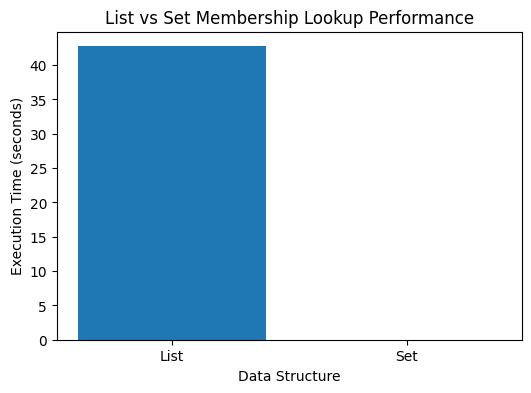

In [23]:
plt.figure(figsize=(6,4))

plt.bar(
    results_benchmark["Data Structure"],
    results_benchmark["Execution Time (s)"]
)

plt.title("List vs Set Membership Lookup Performance")
plt.ylabel("Execution Time (seconds)")
plt.xlabel("Data Structure")

plt.show()

In [16]:
# Efficient deduplication
class TripRecord:
    def __init__(
        self,
        pickup_datetime,
        dropoff_datetime,
        pu_location,
        do_location,
        fare_amoung
    ):
        self.pickup_datetime = pickup_datetime
        self.dropoff_datetime = dropoff_datetime
        self.pu_location = pu_location
        self.do_location = do_location
        self.fare_amount = fare_amoung

    def __eq__(self, other):
        if not isinstance(other, TripRecord):
            return NotImplemented
        
        return (
            self.pickup_datetime == other.pickup_datetime
            and self.dropoff_datetime == other.dropoff_datetime
            and self.pu_location == other.pu_location
            and self.do_location == other.do_location
            and self.fare_amount == other.fare_amount
        )
    def __hash__(self):
        return hash(
            (
                self.pickup_datetime,
                self.dropoff_datetime,
                self.pu_location,
                self.do_location,
                self.fare_amount
            )
        )
    def __repr__(self):
        return (
            f"TripRecord("
            f"PU={self.pu_location}, "
            f"DO={self.do_location}, "
            f"Fare={self.fare_amount}"
            f")"
        )

In [17]:
trip_records = []

for _, row in trip.iterrows():
    trip_records.append(
        TripRecord(
            row["tpep_pickup_datetime"],
            row["tpep_dropoff_datetime"],
            row["PULocationID"],
            row["DOLocationID"],
            row["fare_amount"]
        )
    )

unique_trips = set(trip_records)

In [18]:
print(f"Original trips: {len(trip_records):,}")
print(f"Unique trips: {len(unique_trips):,}")
print(f"Duplicates removed: {len(trip_records) - len(unique_trips):,}")

Original trips: 2,964,624
Unique trips: 2,964,500
Duplicates removed: 124


In [ ]:
# __repr__
print(next(iter(unique_trips)))

TripRecord(PU=263, DO=141, Fare=7.2)


Trip Aggregates

In [5]:
def aggregate_trip_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df['date'] = pd.to_datetime(df["tpep_pickup_datetime"]).dt.date
    df['hour'] = pd.to_datetime(df["tpep_pickup_datetime"]).dt.hour

    return (
        df.groupby(['date', 'hour', 'Borough'], as_index=False)
        .agg(
            total_trips=('Borough', 'size'),
            avg_fare=('fare_amount', 'mean'),
            median_fare=('fare_amount', 'median'),
            total_revenue=('fare_amount', 'sum'),
            avg_distance=('trip_distance', 'mean')
        )
    )

def add_borough(trips_df: pd.DataFrame, zones_df: pd.DataFrame) -> pd.DataFrame:
    return trips_df.merge(
        zones_df[["LocationID", "Borough"]],
        left_on="PULocationID",
        right_on="LocationID",
        how='left',
        validate='many_to_one'
    )

merged_df = add_borough(trip, zone)
agg_trip = aggregate_trip_metrics(merged_df)
agg_trip.head()

,date,hour,Borough,total_trips,avg_fare,median_fare,total_revenue,avg_distance
0,2002-12-31,22,Manhattan,2,0.000000,0.0,0.0,0.630000
1,2009-01-01,0,Queens,1,50.600000,50.6,50.6,10.880000
2,2009-01-01,23,Manhattan,2,24.700000,24.7,49.4,5.725000
3,2023-12-31,23,Manhattan,9,12.333333,10.0,111.0,1.957778
4,2023-12-31,23,Queens,1,33.100000,33.1,33.1,8.390000


7-day rolling average of trip count by location

In [ ]:
def get_daily_trip_counts(df: pd.DataFrame) -> pd.DataFrame:
    df["trip_date"] = pd.to_datetime(
        df["tpep_pickup_datetime"]
    ).dt.date

    return (
        df.groupby(
            ['trip_date', 'PULocationID'],
            as_index=False
        )
        .size()
        .rename(columns={'size': 'trip_count'})
    )

def add_rolling_average(df: pd.DataFrame) -> pd.DataFrame:
    df["trip_date"] = pd.to_datetime(df['trip_date'])
    df = df.sort_values(
        ["PULocationID", "trip_date"]
    )

    df["rolling_avg_7d"] = (
        df.groupby("PULocationID")["trip_count"]
        .transform(
            lambda x: x.rolling(
                window=7,
                min_periods=1
            ).mean()
        )
    )
    return df

In [6]:
daily_counts = get_daily_trip_counts(trip)
daily_counts = add_rolling_average(daily_counts)
daily_counts.head()

,trip_date,PULocationID,trip_count,rolling_avg_7d
14,2024-01-01,1,21,21.00
247,2024-01-02,1,20,20.50
469,2024-01-03,1,16,19.00
697,2024-01-04,1,10,16.75
919,2024-01-05,1,8,15.00


Rush hour trips

In [10]:
def filter_rush_hour_trips(df: pd.DataFrame) -> pd.DataFrame:
    pickup_dt = pd.to_datetime(df["tpep_pickup_datetime"])

    df['hour'] = pickup_dt.dt.hour
    df['day_of_week'] = pickup_dt.dt.dayofweek

    return df.query(
        "fare_amount > 20 and day_of_week < 5 and ((hour >= 7 and hour <= 10) or (hour >= 16 and hour <= 19))"
    )

In [12]:
output = filter_rush_hour_trips(trip)
print(output.head())

       VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
24772         2  2024-01-01 07:00:53   2024-01-01 07:15:22              5.0   
24896         1  2024-01-01 07:07:13   2024-01-01 07:24:47              1.0   
24902         1  2024-01-01 07:36:40   2024-01-01 07:53:11              1.0   
24905         2  2024-01-01 07:23:01   2024-01-01 08:11:07              1.0   
24907         2  2024-01-01 07:37:49   2024-01-01 08:13:21              5.0   

       trip_distance  RatecodeID store_and_fwd_flag  PULocationID  \
24772          13.12         5.0                  N           145   
24896           5.00         1.0                  N           142   
24902           5.10         1.0                  N           263   
24905          15.09         1.0                  N           151   
24907          22.23         2.0                  N           132   

       DOLocationID  payment_type  ...  mta_tax  tip_amount  tolls_amount  \
24772           216             1